# SHAP explainability for AqSolDB random forest

Explains the trained classifier with SHAP values and plots per-bit importance.

In [10]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# configure plotting
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)


In [11]:
# Load the dataset
# This notebook expects to be run from the qspr directory.
df = pd.read_csv('AqSolDB_v1.0_min.csv')
print(df.shape)
df.head()


(9982, 5)


,ID,Name,InChIKey,SMILES,Solubility
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065


In [12]:
# Convert SMILES to molecules and compute ECFP fingerprints
RADIUS = 2
N_BITS = 100
CHIRAL = True

def smiles_to_mol(s):
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS, includeChirality=CHIRAL)
df['mol'] = df['SMILES'].astype(str).map(smiles_to_mol)
df['ECFP'] = df['mol'].map(lambda mol: morgan_generator.GetFingerprint(mol) if mol is not None else None)

# Drop rows where fingerprint or solubility is missing
df = df.dropna(subset=['ECFP', 'Solubility']).copy()
print('Remaining molecules:', len(df))


[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not removing hydrogen atom without neighbors
[08:17:43] WARNING: not r

Remaining molecules: 9980


In [13]:
# Build feature matrix X and binary target y (median split)
X = np.zeros((len(df), N_BITS), dtype=np.int8)
for i, fp in enumerate(df['ECFP']):
    arr = np.zeros((N_BITS,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    X[i] = arr

target_threshold = df['Solubility'].median()
df['is_soluble'] = (df['Solubility'] >= target_threshold).astype(int)
y = df['is_soluble'].to_numpy()
feature_names = [f'bit_{i}' for i in range(N_BITS)]

print('X shape:', X.shape, 'y positive rate:', y.mean())


X shape: (9980, 100) y positive rate: 0.5


In [14]:
# Train/test split and fit a random forest classifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= 0.5).astype(int)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, proba))


Accuracy: 0.7975951903807615
ROC AUC: 0.8715777134317623


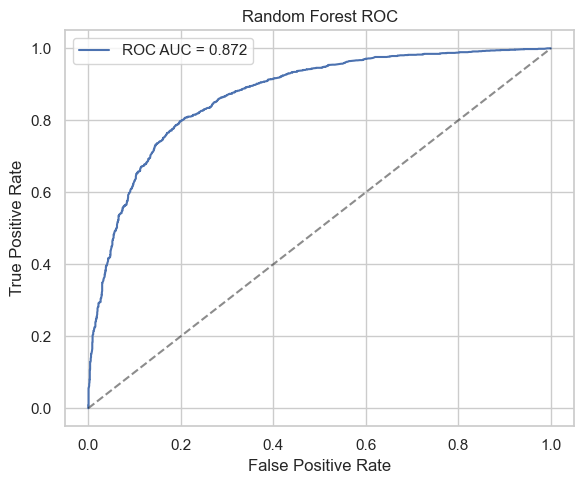

In [15]:
# ROC curve
g0, g1, _ = roc_curve(y_test, proba)
plt.figure(figsize=(6, 5))
plt.plot(g0, g1, label=f'ROC AUC = {roc_auc_score(y_test, proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC')
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# Compute SHAP values (pick class 1 if multi-output)
explainer = shap.TreeExplainer(rf, feature_perturbation='tree_path_dependent', approximate=True)
shap_values = explainer.shap_values(X_test)

# Harmonize shape across shap versions
shap_values = np.array(shap_values)
if shap_values.ndim == 3 and shap_values.shape[-1] == 2:
    shap_values = shap_values[:, :, 1]
elif shap_values.ndim == 3 and shap_values.shape[0] == 2:
    shap_values = shap_values[1]

print('SHAP values shape:', shap_values.shape)


SHAP values shape: (2994, 100)


/var/folders/57/6qhcwb4s0b5216xtqrw53zcw0000gn/T/ipykernel_49173/970040470.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


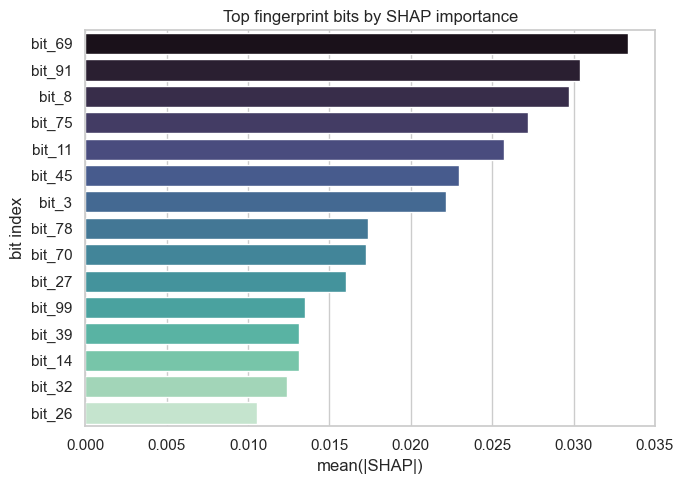

,bit,mean_abs_shap,relative_importance,activation_rate,relative_importance_pct
69,bit_69,0.033353,0.053939,0.642685,5.393948
91,bit_91,0.030421,0.049197,0.387675,4.919680
8,bit_8,0.029696,0.048025,0.671443,4.802469
75,bit_75,0.027183,0.043960,0.301703,4.396003
11,bit_11,0.025752,0.041646,0.407415,4.164583
45,bit_45,0.022946,0.037108,0.271343,3.710844
3,bit_3,0.022183,0.035875,0.309519,3.587473
78,bit_78,0.017344,0.028048,0.162826,2.804814
70,bit_70,0.017220,0.027848,0.538577,2.784796
27,bit_27,0.015989,0.025857,0.248998,2.585687


In [17]:
# Bit-level SHAP importances (absolute and relative)
mean_abs = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'bit': feature_names,
    'mean_abs_shap': mean_abs,
    'relative_importance': mean_abs / mean_abs.sum(),
    'activation_rate': X.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

top_n = 15
plt.figure(figsize=(7, 5))
sns.barplot(
    data=importance_df.head(top_n),
    x='mean_abs_shap',
    y='bit',
    palette='mako'
)
plt.xlabel('mean(|SHAP|)')
plt.ylabel('bit index')
plt.title('Top fingerprint bits by SHAP importance')
plt.tight_layout()
plt.show()

importance_df.head(top_n).assign(relative_importance_pct=lambda d: d['relative_importance'] * 100)


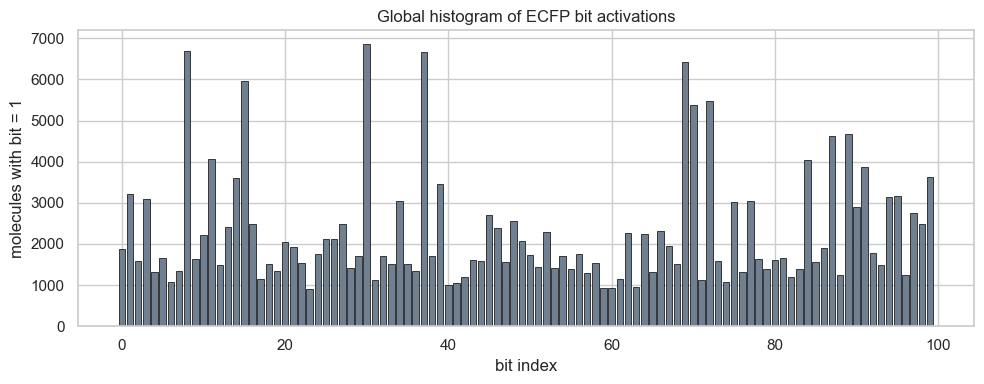

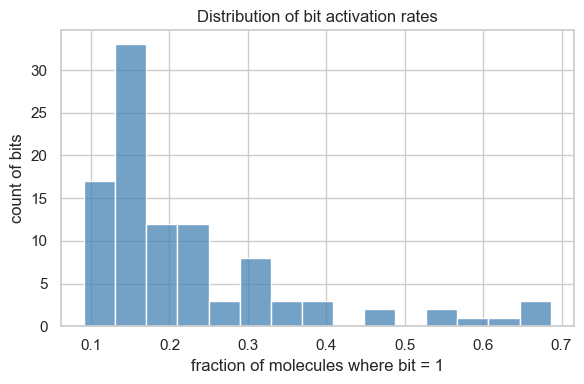

In [18]:
# Global histogram of fingerprint bit activations
bit_counts = X.sum(axis=0)
plt.figure(figsize=(10, 4))
plt.bar(np.arange(N_BITS), bit_counts, color='slategray', edgecolor='black', linewidth=0.5)
plt.xlabel('bit index')
plt.ylabel('molecules with bit = 1')
plt.title('Global histogram of ECFP bit activations')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(X.mean(axis=0), bins=15, color='steelblue')
plt.xlabel('fraction of molecules where bit = 1')
plt.ylabel('count of bits')
plt.title('Distribution of bit activation rates')
plt.tight_layout()
plt.show()


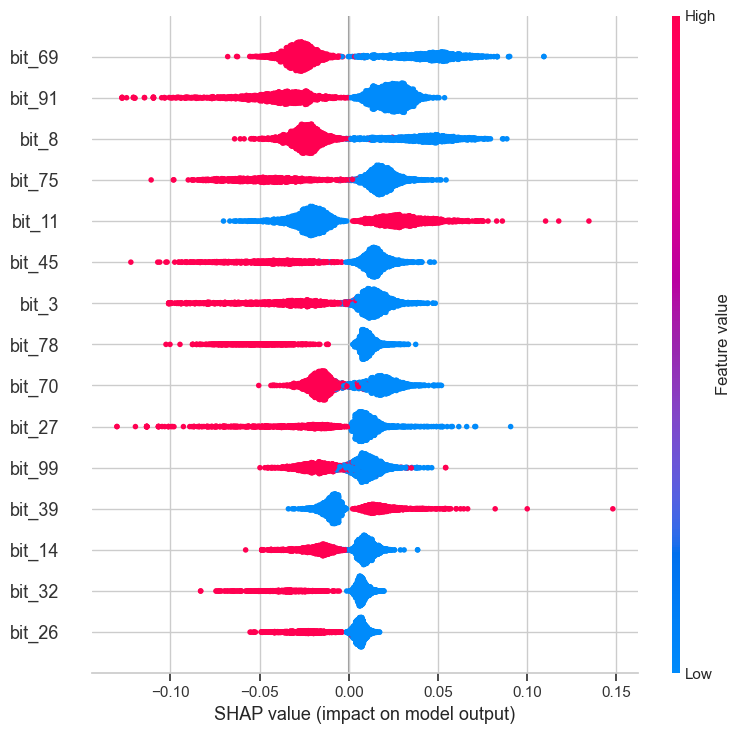

In [19]:
# Beeswarm plot for the top features
# shap.summary_plot expects shape (samples, features)
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=True, max_display=15)
